In [1]:
#imports and config

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path



In [2]:
# paths
fact_root = Path("/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/silver/comtrade/comtrade_fact")
fact_files = sorted(fact_root.rglob("ref_year=*/reporter_iso3=*/*.parquet"))



In [3]:
#raw load
silver_df = pd.concat(
    [pd.read_parquet(str(path)) for path in fact_files],
    ignore_index=True,
)


silver_df.shape

(1085896, 65)

In [4]:
#schema audit

silver_grain = ["period", "reporter_iso3", "partner_iso3", "flowCode", "cmdCode", "classification_version","customsCode", "motCode", "partner2Code"]

dup_count = silver_df.duplicated(subset=silver_grain).sum()
dup_count

np.int64(0)

In [5]:
silver_df.drop_duplicates(subset=silver_grain, inplace=True)

In [6]:
silver_df.shape

(1085896, 65)

In [7]:
import importlib.util

country_preview = (
    pd.concat(
        [
            silver_df[["reporter_iso3", "reporter_name_clean"]].rename(
                columns={"reporter_iso3": "iso3", "reporter_name_clean": "country_name"}
            ),
            silver_df[["partner_iso3", "partner_name_clean"]].rename(
                columns={"partner_iso3": "iso3", "partner_name_clean": "country_name"}
            ),
        ],
        ignore_index=True,
    )
    .dropna(subset=["iso3"])
    .drop_duplicates()
    .sort_values(["iso3", "country_name"])
)

inspection = {
    "country_rows": len(country_preview),
    "country_sample": country_preview.head(20),
    "non_alpha_iso3": country_preview.loc[~country_preview["iso3"].astype(str).str.fullmatch(r"[A-Z]{3}"), ["iso3", "country_name"]],
    "library_check": {
        "pycountry": importlib.util.find_spec("pycountry") is not None,
        "country_converter": importlib.util.find_spec("country_converter") is not None,
        "pycountry_convert": importlib.util.find_spec("pycountry_convert") is not None,
    },
}
inspection

{'country_rows': 240,
 'country_sample':         iso3               country_name
 1431959  A79                  LAIA, nes
 1841949  A79       Rest of America, nes
 1161436  ABW                      Aruba
 1095709  AFG                Afghanistan
 1095710  AGO                     Angola
 1166237  AIA                   Anguilla
 1085896  ALB                    Albania
 1099368  AND                    Andorra
 1086733  ARE       United Arab Emirates
 1085900  ARG                  Argentina
 1085904  ARM                    Armenia
 1514008  ASM             American Samoa
 1173728  ATA                 Antarctica
 1164700  ATF  Fr. South Antarctic Terr.
 1085908  ATG        Antigua and Barbuda
 1095717  AUS                  Australia
 1085912  AUT                    Austria
 1086770  AZE                 Azerbaijan
 1098724  BDI                    Burundi
 1085939  BEL                    Belgium,
 'non_alpha_iso3':         iso3          country_name
 1431959  A79             LAIA, nes
 1841949

In [8]:
import country_converter as coco

cc = coco.CountryConverter()
sample_iso3 = ["USA", "FRA", "CHN", "BRA", "AUS", "ZAF", "IND"]
{
    "UNregion": cc.convert(sample_iso3, src="ISO3", to="UNregion"),
    "continent": cc.convert(sample_iso3, src="ISO3", to="continent"),
    "Continent_7": cc.convert(sample_iso3, src="ISO3", to="Continent_7"),
    "EXIO3": cc.convert(sample_iso3, src="ISO3", to="EXIO3"),
}

{'UNregion': ['Northern America',
  'Western Europe',
  'Eastern Asia',
  'South America',
  'Australia and New Zealand',
  'Southern Africa',
  'Southern Asia'],
 'continent': ['America',
  'Europe',
  'Asia',
  'America',
  'Oceania',
  'Africa',
  'Asia'],
 'Continent_7': ['North America',
  'Europe',
  'Asia',
  'South America',
  'Oceania',
  'Africa',
  'Asia'],
 'EXIO3': ['US', 'FR', 'CN', 'BR', 'AU', 'ZA', 'IN']}

Builds dim_country with columns country_code, iso3, country_name, region, subregion, continent, is_eu, is_oecd using:
reporters.csv
partners.csv
and country_converter (with explicit overrides for grouped codes like A79, S19, W00, EUR).

In [9]:
# dim_country
import country_converter as coco

metadata_root = Path("/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/metadata/comtrade")

reporters_meta = pd.read_csv(metadata_root / "reporters.csv")
partners_meta = pd.read_csv(metadata_root / "partners.csv")

def _normalize_iso3(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().str.upper().replace({"": pd.NA, "NAN": pd.NA})

country_meta = pd.concat(
    [
        reporters_meta[["reporterCode", "reporterCodeIsoAlpha3", "text"]].rename(
            columns={
                "reporterCode": "country_code",
                "reporterCodeIsoAlpha3": "iso3",
                "text": "country_name",
            }
        ),
        partners_meta[["PartnerCode", "PartnerCodeIsoAlpha3", "text"]].rename(
            columns={
                "PartnerCode": "country_code",
                "PartnerCodeIsoAlpha3": "iso3",
                "text": "country_name",
            }
        ),
    ],
    ignore_index=True,
)

country_meta["iso3"] = _normalize_iso3(country_meta["iso3"])
country_meta = country_meta.dropna(subset=["iso3", "country_name"])
country_meta["country_name"] = country_meta["country_name"].astype(str).str.strip()

iso3_universe = (
    pd.concat([silver_df["reporter_iso3"], silver_df["partner_iso3"]], ignore_index=True)
    .dropna()
    .astype(str)
    .str.strip()
    .str.upper()
    .drop_duplicates()
)

dim_country = (
    country_meta.loc[country_meta["iso3"].isin(iso3_universe)]
    .sort_values(["iso3", "country_code"])
    .drop_duplicates(subset=["iso3"], keep="first")
    .reset_index(drop=True)
)

# Fallback names when metadata has a gap for active codes
name_fallback = (
    pd.concat(
        [
            silver_df[["reporter_iso3", "reporter_name_clean"]].rename(columns={"reporter_iso3": "iso3", "reporter_name_clean": "country_name"}),
            silver_df[["partner_iso3", "partner_name_clean"]].rename(columns={"partner_iso3": "iso3", "partner_name_clean": "country_name"}),
        ],
        ignore_index=True,
    )
    .dropna()
)
name_fallback["iso3"] = _normalize_iso3(name_fallback["iso3"])
name_fallback = name_fallback.dropna(subset=["iso3"]).drop_duplicates(subset=["iso3"], keep="first")

missing_iso3 = sorted(set(iso3_universe) - set(dim_country["iso3"]))
if missing_iso3:
    missing_df = name_fallback.loc[name_fallback["iso3"].isin(missing_iso3), ["iso3", "country_name"]].copy()
    missing_df["country_code"] = pd.NA
    dim_country = pd.concat([dim_country, missing_df[["country_code", "iso3", "country_name"]]], ignore_index=True)

cc = coco.CountryConverter()
custom_group_codes = {"A79", "E19", "F19", "S19", "W00", "X1", "XX", "_X", "EUR"}
valid_iso3_mask = dim_country["iso3"].str.fullmatch(r"[A-Z]{3}") & ~dim_country["iso3"].isin(custom_group_codes)

# Initialize geography columns before classification
for column_name in ["subregion", "continent", "region"]:
    dim_country[column_name] = pd.NA

dim_country.loc[valid_iso3_mask, "subregion"] = cc.convert(
    names=dim_country.loc[valid_iso3_mask, "iso3"].tolist(), src="ISO3", to="UNregion"
)
dim_country.loc[valid_iso3_mask, "continent"] = cc.convert(
    names=dim_country.loc[valid_iso3_mask, "iso3"].tolist(), src="ISO3", to="Continent_7"
)
dim_country.loc[valid_iso3_mask, "region"] = dim_country.loc[valid_iso3_mask, "continent"].replace(
    {"North America": "Americas", "South America": "Americas", "America": "Americas"}
)

# EU/OECD membership from raw converter table columns.
cc_membership = cc.data[["ISO3", "EU", "OECD"]].copy()
cc_membership["ISO3"] = cc_membership["ISO3"].astype(str).str.strip().str.upper()

membership_map = cc_membership.rename(columns={"ISO3": "iso3", "EU": "_cc_eu", "OECD": "_cc_oecd"})
dim_country = dim_country.merge(membership_map, on="iso3", how="left")

dim_country["is_eu"] = dim_country["_cc_eu"].astype("string").str.strip().str.upper().eq("EU")
dim_country["is_oecd"] = dim_country["_cc_oecd"].notna()

group_overrides = {
    "A79": {"region": "Americas", "subregion": "Latin America and the Caribbean", "continent": "Americas"},
    "E19": {"region": "Europe", "subregion": "Europe (other/nes)", "continent": "Europe"},
    "F19": {"region": "Africa", "subregion": "Africa (other/nes)", "continent": "Africa"},
    "S19": {"region": "Asia", "subregion": "Asia (other/nes)", "continent": "Asia"},
    "W00": {"region": "World", "subregion": "World", "continent": "World"},
    "X1": {"region": "Special", "subregion": "Bunkers", "continent": "Special"},
    "XX": {"region": "Special", "subregion": "Special Categories", "continent": "Special"},
    "_X": {"region": "Special", "subregion": "Areas, nes", "continent": "Special"},
    "EUR": {"region": "Europe", "subregion": "European Union", "continent": "Europe"},
}

for code, values in group_overrides.items():
    mask = dim_country["iso3"].eq(code)
    if mask.any():
        for column_name, value in values.items():
            dim_country.loc[mask, column_name] = value

dim_country.loc[dim_country["iso3"].eq("EUR"), "is_eu"] = True

# Group entities are not countries and should not be OECD members.
dim_country.loc[dim_country["iso3"].isin(custom_group_codes), "is_oecd"] = False

dim_country = dim_country[["country_code", "iso3", "country_name", "region", "subregion", "continent", "is_eu", "is_oecd"]].sort_values("iso3").reset_index(drop=True)

dim_country.head(20), dim_country.shape

(    country_code iso3               country_name      region  \
 0            473  A79                  LAIA, nes    Americas   
 1            533  ABW                      Aruba    Americas   
 2              4  AFG                Afghanistan        Asia   
 3             24  AGO                     Angola      Africa   
 4            660  AIA                   Anguilla    Americas   
 5              8  ALB                    Albania      Europe   
 6             20  AND                    Andorra      Europe   
 7            784  ARE       United Arab Emirates        Asia   
 8             32  ARG                  Argentina    Americas   
 9             51  ARM                    Armenia        Asia   
 10            16  ASM             American Samoa     Oceania   
 11            10  ATA                 Antarctica  Antarctica   
 12           260  ATF  Fr. South Antarctic Terr.  Antarctica   
 13            28  ATG        Antigua and Barbuda    Americas   
 14            36  AUS   

In [10]:
# dim_commodity
commodity_base = (
    silver_df[["cmdCode", "cmdDesc"]]
    .dropna(subset=["cmdCode"])
    .drop_duplicates()
    .copy()
)

commodity_base["cmdCode"] = commodity_base["cmdCode"].astype(str).str.strip()
commodity_base["hs6"] = commodity_base["cmdCode"].str.pad(6, side="right", fillchar="0").str[:6]
commodity_base["hs4"] = commodity_base["hs6"].str[:4]
commodity_base["hs2"] = commodity_base["hs6"].str[:2]

hs2_num = pd.to_numeric(commodity_base["hs2"], errors="coerce")

commodity_base["commodity_group"] = np.select(
    [
        hs2_num.between(1, 24, inclusive="both"),
        hs2_num.between(25, 27, inclusive="both"),
        hs2_num.between(28, 38, inclusive="both"),
        hs2_num.between(39, 40, inclusive="both"),
    ],
    [
        "Food",
        "Energy / raw materials",
        "Chemicals",
        "Plastics",
    ],
    default="Other",
)

commodity_base["food_flag"] = commodity_base["commodity_group"].eq("Food")
commodity_base["energy_flag"] = commodity_base["commodity_group"].eq("Energy / raw materials")
commodity_base["industrial_flag"] = hs2_num.between(28, 40, inclusive="both")

dim_commodity = (
    commodity_base.rename(columns={"cmdDesc": "commodity_name"})[
        [
            "cmdCode",
            "hs2",
            "hs4",
            "hs6",
            "commodity_name",
            "commodity_group",
            "food_flag",
            "energy_flag",
            "industrial_flag",
        ]
    ]
    .sort_values(["cmdCode", "commodity_name"])
    .reset_index(drop=True)
)

dim_commodity.head(20), dim_commodity.shape

(  cmdCode hs2   hs4     hs6  \
 0    1001  10  1001  100100   
 1    1005  10  1005  100500   
 2    1006  10  1006  100600   
 3    1201  12  1201  120100   
 4    2709  27  2709  270900   
 5    2710  27  2710  271000   
 
                                       commodity_name         commodity_group  \
 0                                   Wheat and meslin                    Food   
 1                                       Maize (corn)                    Food   
 2                                               Rice                    Food   
 3                  Soya beans, whether or not broken                    Food   
 4  Petroleum oils and oils obtained from bitumino...  Energy / raw materials   
 5  Petroleum oils and oils from bituminous minera...  Energy / raw materials   
 
    food_flag  energy_flag  industrial_flag  
 0       True        False            False  
 1       True        False            False  
 2       True        False            False  
 3       True        

In [11]:
# dim_trade_flow
metadata_root = Path("/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/metadata/comtrade")
flows_meta = pd.read_csv(metadata_root / "flows.csv")

dim_trade_flow = (
    flows_meta.rename(columns={"id": "flowCode", "text": "flowDesc"})[["flowCode", "flowDesc"]]
    .drop_duplicates()
    .copy()
)

dim_trade_flow["flowCode"] = dim_trade_flow["flowCode"].astype(str).str.strip().str.upper()

dim_trade_flow["flow_group"] = np.select(
    [dim_trade_flow["flowCode"].eq("M"), dim_trade_flow["flowCode"].eq("X")],
    ["Import", "Export"],
    default="Other",
)

flow_in_fact = set(silver_df["flowCode"].dropna().astype(str).str.strip().str.upper())
dim_trade_flow = dim_trade_flow.loc[dim_trade_flow["flowCode"].isin(flow_in_fact)].sort_values("flowCode").reset_index(drop=True)

dim_trade_flow

,flowCode,flowDesc,flow_group
0,M,Import,Import
1,X,Export,Export


In [12]:
# dim_time
dim_time = pd.DataFrame({"period": pd.Series(silver_df["period"].dropna().unique(), dtype="Int64")})

dim_time = dim_time.sort_values("period").reset_index(drop=True)
dim_time["year"] = dim_time["period"] // 100
dim_time["month"] = dim_time["period"] % 100
dim_time["quarter"] = ((dim_time["month"] - 1) // 3 + 1).astype("Int64")
dim_time["year_month"] = dim_time["year"].astype(str) + "-" + dim_time["month"].astype(int).astype(str).str.zfill(2)
dim_time["date"] = pd.to_datetime(dim_time["year_month"] + "-01", format="%Y-%m-%d", errors="coerce")

dim_time = dim_time[["period", "year", "month", "quarter", "year_month", "date"]]

dim_time.head(12), dim_time.shape

(    period  year  month  quarter year_month       date
 0   202001  2020      1        1    2020-01 2020-01-01
 1   202002  2020      2        1    2020-02 2020-02-01
 2   202003  2020      3        1    2020-03 2020-03-01
 3   202004  2020      4        2    2020-04 2020-04-01
 4   202005  2020      5        2    2020-05 2020-05-01
 5   202006  2020      6        2    2020-06 2020-06-01
 6   202007  2020      7        3    2020-07 2020-07-01
 7   202008  2020      8        3    2020-08 2020-08-01
 8   202009  2020      9        3    2020-09 2020-09-01
 9   202010  2020     10        4    2020-10 2020-10-01
 10  202011  2020     11        4    2020-11 2020-11-01
 11  202012  2020     12        4    2020-12 2020-12-01,
 (72, 6))

In [13]:
#dimension quality snapshot
{
    "dim_country_rows": len(dim_country),
    "dim_country_missing_geography": dim_country[["region", "subregion", "continent"]].isna().any(axis=1).sum(),
    "dim_commodity_rows": len(dim_commodity),
    "dim_trade_flow_rows": len(dim_trade_flow),
    "dim_time_rows": len(dim_time),
}

{'dim_country_rows': 239,
 'dim_country_missing_geography': np.int64(0),
 'dim_commodity_rows': 6,
 'dim_trade_flow_rows': 2,
 'dim_time_rows': 72}

In [14]:
#write dimensions
output_root = Path("/Users/chromazone/Documents/Python/Data Enginering Zoomcamp/Capstone_monthly/data/silver/comtrade/dimensions")
output_root.mkdir(parents=True, exist_ok=True)

dim_country.to_parquet(output_root / "dim_country.parquet", index=False)
dim_commodity.to_parquet(output_root / "dim_commodity.parquet", index=False)
dim_trade_flow.to_parquet(output_root / "dim_trade_flow.parquet", index=False)
dim_time.to_parquet(output_root / "dim_time.parquet", index=False)

sorted(str(path.name) for path in output_root.glob("*.parquet"))

['dim_commodity.parquet',
 'dim_country.parquet',
 'dim_time.parquet',
 'dim_trade_flow.parquet']

In [15]:
#verification read-back
checks = {
    "dim_country": pd.read_parquet(output_root / "dim_country.parquet").shape,
    "dim_commodity": pd.read_parquet(output_root / "dim_commodity.parquet").shape,
    "dim_trade_flow": pd.read_parquet(output_root / "dim_trade_flow.parquet").shape,
    "dim_time": pd.read_parquet(output_root / "dim_time.parquet").shape,
}
checks

{'dim_country': (239, 8),
 'dim_commodity': (6, 9),
 'dim_trade_flow': (2, 3),
 'dim_time': (72, 6)}

In [16]:
#sample analysis-ready slices
country_slice = dim_country.loc[dim_country["iso3"].isin(["USA", "CHN", "EUR", "NLD", "S19"])]
commodity_slice = dim_commodity[["cmdCode", "commodity_group", "food_flag", "energy_flag", "industrial_flag"]].head(10)

country_slice, commodity_slice

(     country_code iso3              country_name    region         subregion  \
 42            156  CHN                     China      Asia      Eastern Asia   
 72             97  EUR            European Union    Europe    European Union   
 156           528  NLD               Netherlands    Europe    Western Europe   
 179           490  S19           Other Asia, nes      Asia  Asia (other/nes)   
 221           840  USA  United States of America  Americas  Northern America   
 
          continent is_eu  is_oecd  
 42            Asia  <NA>    False  
 72          Europe  True    False  
 156         Europe  True     True  
 179           Asia  <NA>    False  
 221  North America  <NA>     True  ,
   cmdCode         commodity_group  food_flag  energy_flag  industrial_flag
 0    1001                    Food       True        False            False
 1    1005                    Food       True        False            False
 2    1006                    Food       True        False   

In [17]:
#analysis-ready star-schema fact table
reporter_dim = dim_country.rename(
    columns={
        "iso3": "reporter_iso3",
        "country_code": "reporter_country_code",
        "country_name": "reporter_country_name",
        "region": "reporter_region",
        "subregion": "reporter_subregion",
        "continent": "reporter_continent",
        "is_eu": "reporter_is_eu",
        "is_oecd": "reporter_is_oecd",
    }
)

partner_dim = dim_country.rename(
    columns={
        "iso3": "partner_iso3",
        "country_code": "partner_country_code",
        "country_name": "partner_country_name",
        "region": "partner_region",
        "subregion": "partner_subregion",
        "continent": "partner_continent",
        "is_eu": "partner_is_eu",
        "is_oecd": "partner_is_oecd",
    }
)

fact_star = silver_df.copy()
fact_star["cmdCode"] = fact_star["cmdCode"].astype(str).str.strip()
fact_star["flowCode"] = fact_star["flowCode"].astype(str).str.strip().str.upper()

fact_star = (
    fact_star
    .merge(dim_time, on="period", how="left")
    .merge(dim_commodity, on="cmdCode", how="left")
    .merge(dim_trade_flow, on="flowCode", how="left")
    .merge(reporter_dim, on="reporter_iso3", how="left")
    .merge(partner_dim, on="partner_iso3", how="left")
)

star_quality = {
    "fact_star_shape": fact_star.shape,
    "missing_time": int(fact_star["year"].isna().sum()),
    "missing_commodity": int(fact_star["commodity_name"].isna().sum()),
    "missing_flow": int(fact_star["flowDesc"].isna().sum()),
    "missing_reporter_country": int(fact_star["reporter_country_name"].isna().sum()),
    "missing_partner_country": int(fact_star["partner_country_name"].isna().sum()),
}

star_quality, fact_star.head(5)

({'fact_star_shape': (1085896, 94),
  'missing_time': 0,
  'missing_commodity': 0,
  'missing_flow': 0,
  'missing_reporter_country': 0,
  'missing_partner_country': 0},
                load_batch_id  \
 0  20260317T233325Z_46a53589   
 1  20260317T233325Z_46a53589   
 2  20260317T233325Z_46a53589   
 3  20260317T233325Z_46a53589   
 4  20260317T233325Z_46a53589   
 
                                          source_file  source_year_partition  \
 0  hist_batch_reps_100_cmd_1001-1005-1006-1201-27...                   2020   
 1  hist_batch_reps_100_cmd_1001-1005-1006-1201-27...                   2020   
 2  hist_batch_reps_100_cmd_1001-1005-1006-1201-27...                   2020   
 3  hist_batch_reps_100_cmd_1001-1005-1006-1201-27...                   2020   
 4  hist_batch_reps_100_cmd_1001-1005-1006-1201-27...                   2020   
 
                bronze_extracted_at   ref_date year_month_x quarter_x  \
 0 2026-03-12 11:15:40.387684+00:00 2020-01-01      2020-01    2020Q1   
 1

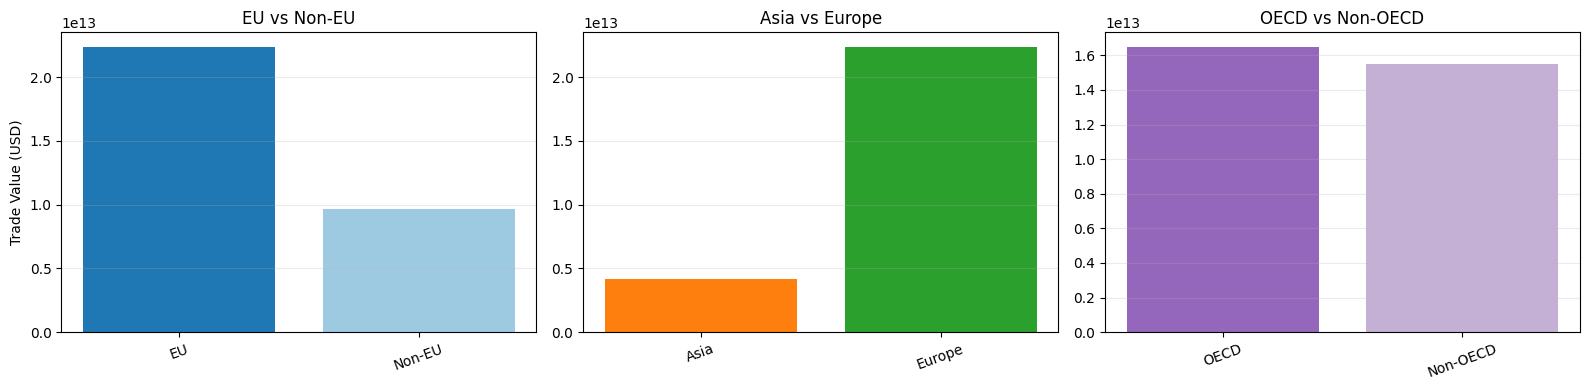

(  eu_group  trade_value_usd
 0       EU     2.238244e+13
 1   Non-EU     9.634119e+12,
   region_group  trade_value_usd
 0         Asia     4.196524e+12
 1       Europe     2.238244e+13,
   oecd_group  trade_value_usd
 0       OECD     1.650778e+13
 1   Non-OECD     1.550878e+13)

In [18]:
#quick comparison charts
chart_df = fact_star.copy()
chart_df["trade_value_usd"] = pd.to_numeric(chart_df["trade_value_usd"], errors="coerce").fillna(0)

reporter_is_eu = chart_df["reporter_is_eu"].fillna(False).astype(bool)
reporter_is_oecd = chart_df["reporter_is_oecd"].fillna(False).astype(bool)

plot_eu = (
    chart_df.assign(eu_group=np.where(reporter_is_eu, "EU", "Non-EU"))
    .groupby("eu_group", as_index=False)["trade_value_usd"]
    .sum()
    .set_index("eu_group")
    .reindex(["EU", "Non-EU"], fill_value=0)
    .reset_index()
)

plot_region = (
    chart_df.loc[chart_df["reporter_region"].isin(["Asia", "Europe"])]
    .groupby("reporter_region", as_index=False)["trade_value_usd"]
    .sum()
    .rename(columns={"reporter_region": "region_group"})
    .set_index("region_group")
    .reindex(["Asia", "Europe"], fill_value=0)
    .reset_index()
)

plot_oecd = (
    chart_df.assign(oecd_group=np.where(reporter_is_oecd, "OECD", "Non-OECD"))
    .groupby("oecd_group", as_index=False)["trade_value_usd"]
    .sum()
    .set_index("oecd_group")
    .reindex(["OECD", "Non-OECD"], fill_value=0)
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(plot_eu["eu_group"], plot_eu["trade_value_usd"], color=["#1f77b4", "#9ecae1"])
axes[0].set_title("EU vs Non-EU")
axes[0].set_ylabel("Trade Value (USD)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(plot_region["region_group"], plot_region["trade_value_usd"], color=["#ff7f0e", "#2ca02c"])
axes[1].set_title("Asia vs Europe")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(plot_oecd["oecd_group"], plot_oecd["trade_value_usd"], color=["#9467bd", "#c5b0d5"])
axes[2].set_title("OECD vs Non-OECD")
axes[2].tick_params(axis="x", rotation=20)

for ax in axes:
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

plot_eu, plot_region, plot_oecd

In [19]:
# OECD diagnostics
debug_iso = ["FRA", "ESP", "NLD", "USA", "CHN", "EUR"]

{
    "oecd_iso3_sample": sorted(list(oecd_iso3))[:15],
    "oecd_iso3_contains_debug": {k: (k in oecd_iso3) for k in debug_iso},
    "dim_country_debug": dim_country.loc[dim_country["iso3"].isin(debug_iso), ["iso3", "country_name", "is_oecd", "is_eu"]],
    "fact_reporter_debug_counts": (
        fact_star.loc[fact_star["reporter_iso3"].isin(debug_iso)]
        .groupby(["reporter_iso3", "reporter_country_name", "reporter_is_oecd"], dropna=False)
        .size()
        .reset_index(name="rows")
        .sort_values(["reporter_iso3", "reporter_is_oecd"])
    ),
    "oecd_true_rows_in_fact": int(fact_star["reporter_is_oecd"].fillna(False).sum()),
}

NameError: name 'oecd_iso3' is not defined

In [20]:
# converter raw membership diagnostics
cc_raw = cc.data.copy()
cc_raw["ISO3"] = cc_raw["ISO3"].astype(str).str.upper()
cc_raw.loc[cc_raw["ISO3"].isin(["FRA", "ESP", "NLD", "USA", "CHN", "DEU", "JPN"]), ["ISO3", "name_short", "EU", "OECD", "UNregion", "Continent_7"]]

,ISO3,name_short,EU,OECD,UNregion,Continent_7
46,CHN,China,NaN,NaN,Eastern Asia,Asia
77,FRA,France,EU,1961.0,Western Europe,Europe
84,DEU,Germany,EU,1961.0,Western Europe,Europe
112,JPN,Japan,NaN,1964.0,Eastern Asia,Asia
156,NLD,Netherlands,EU,1961.0,Western Europe,Europe
204,ESP,Spain,EU,1961.0,Southern Europe,Europe
236,USA,United States,NaN,1961.0,Northern America,North America
